<font size="6"> Simple Linear Regression Project </font>


<font size="5">Modelling the linear relationship between YearsExperience and PACKAGE dataset </font>



<font size="5">Project overview </font>


In this project, I build a Simple Linear Regression model to study the linear relationship between YearsExperience and PACKAGE dataset to predict how YearsExperience effect on how much package you will get.

<font size="5">Python libraries </font>



<font size="4">Python libraries i used for this model:-</font>


• Numpy – It provides a fast numerical array structure and operating functions.

• pandas – It provides tools for data storage, manipulation and analysis tasks.

• Scikit-Learn – The required machine learning library in Python.

• Matplotlib – It is the basic plotting library in Python. It provides tools for making plots.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#  To split our dataset into parts (train & test)
from sklearn.model_selection import train_test_split

#  To train and implementing our model
from sklearn.linear_model import LinearRegression

#  r2_score used to check accuracy of our model
from sklearn.metrics import r2_score

<font size="6"> About our dataset </font>

I got the dataset from <a href="https://www.kaggle.com/datasets/saquib7hussain/placement-dataset"> Kaggle </a>

This dataset contains 2 major attributes YearsExperience, PACKAGE.






<font size="5"> Placement data details </font>

1. "YearsExperience" :  How much experience emplyoes have.

2. "PACKAGE" :  How much package student will get.

In [10]:
#  import the dataset 

df= pd.read_csv(r"C:\Users\parth\Desktop\karan\ML-DL\ML\Projects\regression\simple_linear_models\Salary_dataset.csv")

<font size="6">Exploratory data analysis</font>


First, I import the dataset into the dataframe with the standard read_csv () function of pandas library and assign it to the df variable. Then, I conducted exploratory data analysis to get a feel for the data.



<font size="5">pandas shape attribute</font>



The shape attribute of the pandas dataframe gives the dimensions of the dataframe.

In [11]:
print(df.shape)

(30, 3)


<font size="6"> Pandas drop attributes </font>

The drop attributes of pandas remove the columns we select 

In [12]:
print(df.columns)
df.drop("y", axis="columns", inplace= True)

Index(['y', 'YearsExperience', 'package'], dtype='object')


<font size="5">pandas head() method</font>




I viewed the top 5 rows of the pandas dataframe with the pandas head() method.

In [13]:
print(df.head(5))

   YearsExperience  package
0              1.2  39344.0
1              1.4  46206.0
2              1.6  37732.0
3              2.1  43526.0
4              2.3  39892.0


<font size="5">pandas info() method</font>



I viewed the summary of the dataframe with the pandas info() method

In [14]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   package          30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes
None


<font size="5">pandas describe() method</font>



I look at the descriptive statistics of the dataframe with the pandas describe() method.

In [15]:
print(df.describe())

       YearsExperience        package
count        30.000000      30.000000
mean          5.413333   76004.000000
std           2.837888   27414.429785
min           1.200000   37732.000000
25%           3.300000   56721.750000
50%           4.800000   65238.000000
75%           7.800000  100545.750000
max          10.600000  122392.000000


<font size="6">Independent and Dependent Variables</font>



In this project, I refer Independent variable as Feature/Input variable and Dependent variable as Target/output variable.


<font size="4">So here, Our input/feature variable is : x  &  Our output/target variable is : y  </font> 

In [17]:
y = df['package'].values
x = df['YearsExperience'].values
print(x)
print(y)


[ 1.2  1.4  1.6  2.1  2.3  3.   3.1  3.3  3.3  3.8  4.   4.1  4.1  4.2
  4.6  5.   5.2  5.4  6.   6.1  6.9  7.2  8.   8.3  8.8  9.1  9.6  9.7
 10.4 10.6]
[ 39344.  46206.  37732.  43526.  39892.  56643.  60151.  54446.  64446.
  57190.  63219.  55795.  56958.  57082.  61112.  67939.  66030.  83089.
  81364.  93941.  91739.  98274. 101303. 113813. 109432. 105583. 116970.
 112636. 122392. 121873.]


<font size="6">Visual exploratory data analysis</font>


I visualize the relationship between x and y by plotting a scatterplot between x and y.

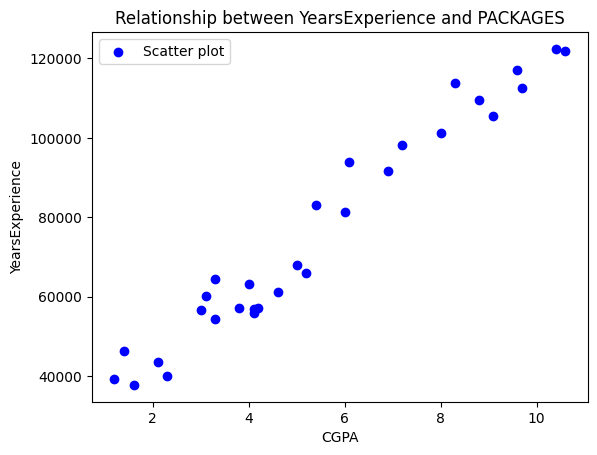

In [41]:
plt.scatter(x,y,color="blue",label="Scatter plot")
plt.title('Relationship between YearsExperience and PACKAGES')
plt.xlabel('CGPA')
plt.ylabel('YearsExperience')
plt.legend(loc=0)
plt.show()

<font size="6">Checking dimensions of X and y</font>


We need to check the dimensions of X and y to make sure they are in right format for Scikit-Learn API.


It is an important precursor to model building.

In [31]:
print(x.shape)
print(y.shape)

(30, 1)
(30, 1)


<font size="6">Reshaping X and y</font>



Since we are working with only one feature variable, so we need to reshape using Numpy reshape() method.

It specifies first dimension to be -1, which means "unspecified".

Its value is inferred from the length of the array and the remaining dimensions

In [32]:
x = x.reshape(-1,1)
y = y.reshape(-1,1)
print(x.shape)
print(y.shape)

(30, 1)
(30, 1)


<font size="6">Train test split</font>


I split the dataset into two sets namely - train set and test set.

The model learn the relationships from the training data and predict on test data

In [33]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(24, 1)
(6, 1)
(24, 1)
(6, 1)


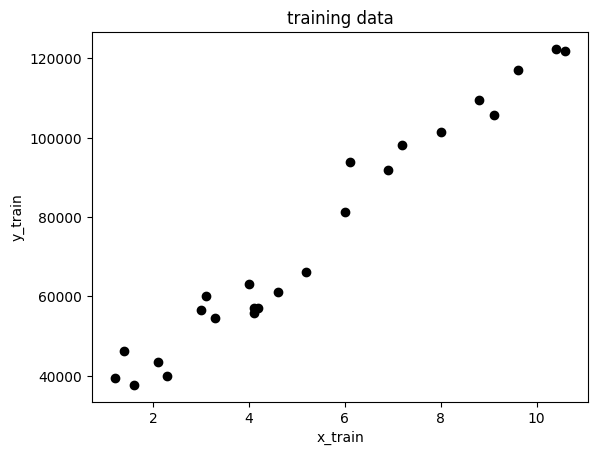

In [43]:
plt.scatter(x_train,y_train,color="black")
plt.title('training data')
plt.xlabel('x_train')
plt.ylabel('y_train')
# plt.legend(loc=0)
plt.show()

<font size="6">Traning of model</font>


I split the dataset into two sets – the training set and the test set. Then, I instantiate the regressor lr and fit it on the training set with the fit method.

In this step, the model learned the relationships between the training data (X_train, y_train).



In [35]:
lr = LinearRegression()
lr.fit(x_train,y_train)
print("Model is trained successfully")

Model is trained successfully


<font size="6">Model's slope and intercept</font>


The model slope/gradiant is given by lr.coef_ and model interception is given by lr.intercept_.

In [36]:
print("The slope/Gradiant of the model is :",lr.coef_)
print("The Interception of the model is :",lr.intercept_)

The slope/Gradiant of the model is : [[9423.81532303]]
The Interception of the model is : [24380.20147947]


<font size="6"> Making prediction </font>

Took the test values to predict, and to check if model is train properly or not.

I predict the model's output by .predict().

To do it, i created the new variable (y_pre).

In [37]:
y_pre = lr.predict(x_test)
# print(x_test)
# print(y_test)
print(y_pre)

[[115791.21011287]
 [ 71499.27809463]
 [102597.86866063]
 [ 75268.80422384]
 [ 55478.79204548]
 [ 60190.69970699]]


In [38]:
y_test

array([[112636.],
       [ 67939.],
       [113813.],
       [ 83089.],
       [ 64446.],
       [ 57190.]])

<font size="6"> Check the accuracy of model </font>

<font size="5">R2 Score</font>



The higher the R2 Score value, the better the model fits the data. Usually, its value ranges from 0 to 1. So, we want its value to be as close to 1. Its value can become negative if our model is wrong


In [39]:
print("Accuracy of model:",r2_score(y_test,y_pre))

Accuracy of model: 0.9024461774180498


The accuracy of model is 0.9024461774180498, that's means model is perfect. My model learns almost everything according to the data i gave to model.



Now, I compare the original/actual output & predicted output by visualization.

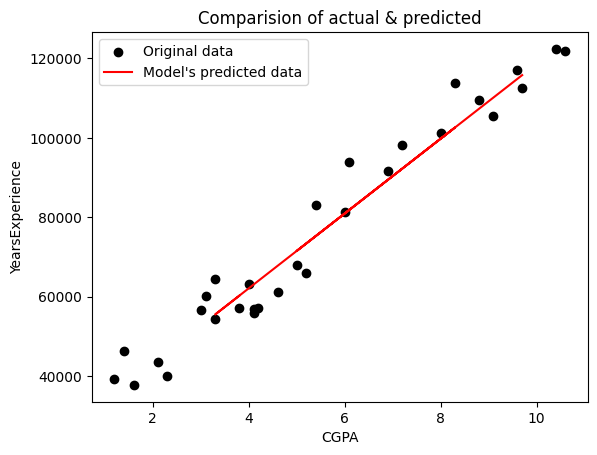

In [42]:
plt.scatter(x,y,color="black",label="Original data")
plt.plot(x_test,y_pre,color="red",label="Model's predicted data")
plt.title('Comparision of actual & predicted')
plt.xlabel('CGPA')
plt.ylabel('YearsExperience')
plt.legend(loc=0)
plt.show()